### Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import statsmodels
import prophet
import sklearn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/test.csv')

### Data Overview

In [ ]:
train_df.shape

(913000, 4)

In [ ]:
train_df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
test_df.head()

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [ ]:
train_df['date'] = pd.to_datetime(train_df['date'])

### EDA

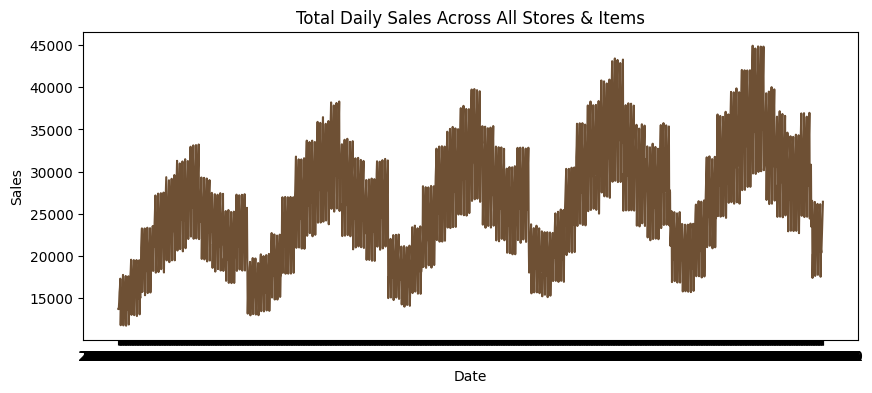

In [ ]:
daily_sales = train_df.groupby('date')['sales'].sum().reset_index()
# 把所有同一天的資料歸在一起
# 再把那一天所有店、所有品項的 sales 加總成一個數字

plt.figure(figsize=(10,4))
plt.plot(daily_sales['date'], daily_sales['sales'], color='#6E5034')
plt.title('Total Daily Sales Across All Stores & Items')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

*  明顯的年度成長趨勢——每年高峰都比前一年高
*  強烈的季節性——每年都是同樣的形狀:年初低、夏季衝高、年底回落,一年一個週期非常規律
*  短週期的鋸齒狀波動

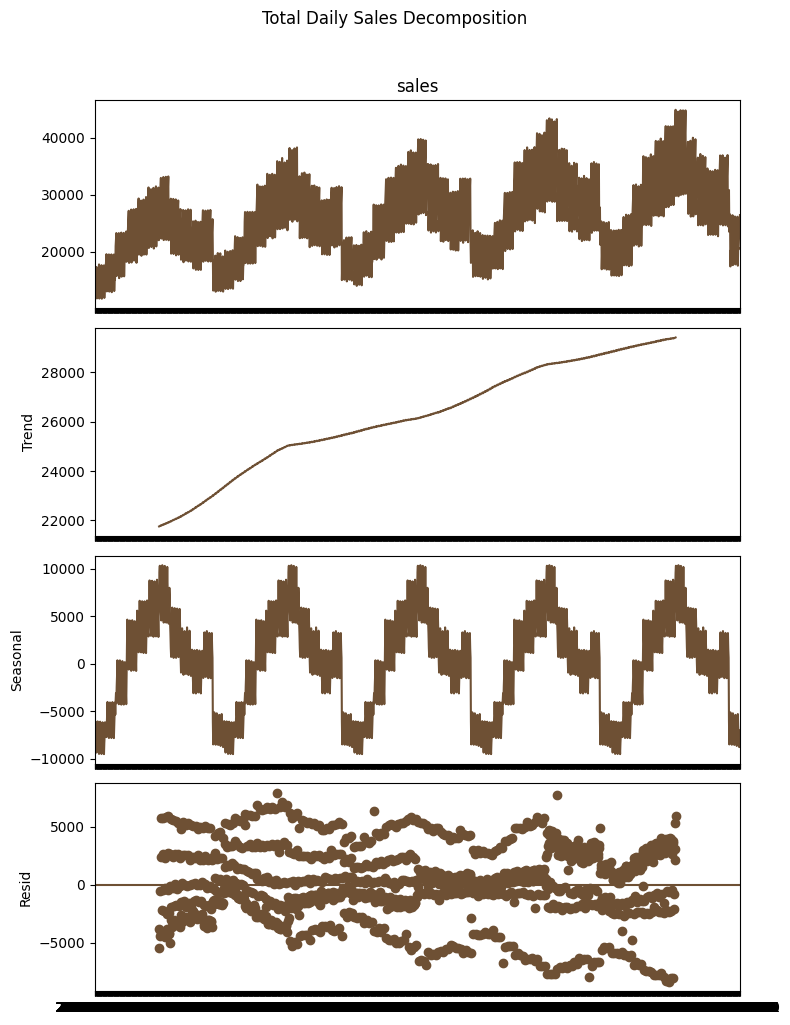

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(daily_sales.set_index('date')['sales'], model='additive', period=365)
fig = decomposition.plot()

fig.set_size_inches(8, 10)

line_color = '#6E5034'

for ax in fig.axes:
    for line in ax.lines:
        line.set_color(line_color)

plt.suptitle('Total Daily Sales Decomposition', y=1.02)
plt.tight_layout()
plt.show()

*   Trend: 把短期波動去掉後,只看「整體方向」。可以看到這條線是穩定往上的——從 2013 年約 22000 一路漲到 2017 年約 29000。代表業務本身是在成長的,不是季節性造成的假象。
*   Seasonal: 這是「每年都會重複出現的固定波動模式」,大約在 -10000 到 +10000 之間規律地上下擺動,一年一個循環。代表每年夏天銷量本來就會比冬天高,這是可預測的規律,不是隨機的。
*   Resid(殘差 / 剩餘):把 Trend 和 Seasonal 都拿掉之後,剩下「解釋不了的雜訊」。這裡看起來範圍大概在 -5000 到 +5000,而且沒有隨時間變寬或變窄,算是相對穩定,沒有明顯的異常模式。

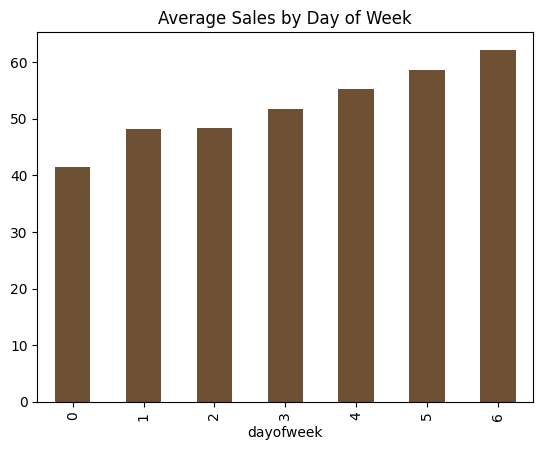

In [ ]:
train_df['dayofweek'] = train_df['date'].dt.dayofweek
train_df.groupby('dayofweek')['sales'].mean().plot(kind='bar', color='#6E5034')
plt.title('Average Sales by Day of Week')
plt.show()

星期效應:
*   星期一(0)銷量最低,約 41
*   銷量從週一到週日持續遞增,週五、六、日(4, 5, 6)明顯較高
*   週日(6)是全週最高,約 62——比週一高了將近 50%

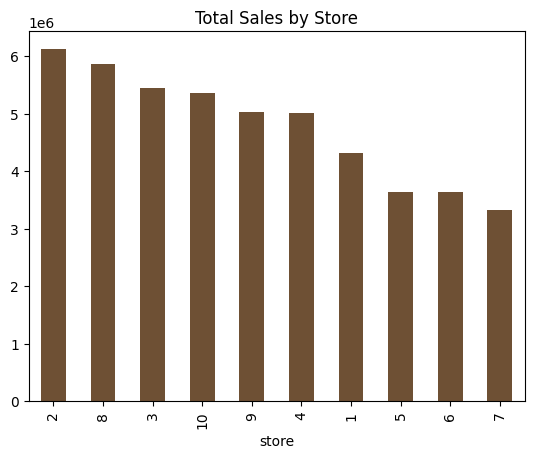

In [ ]:
# store之間的銷量差異
store_sales = train_df.groupby('store')['sales'].sum().sort_values(ascending=False)
store_sales.plot(kind='bar', color='#6E5034')
plt.title('Total Sales by Store')
plt.show()

Store 2 最高,Store 7 最低; 有明顯差異,但不是誇張的落差,所以不需要為每家店建獨立模型,但要把 store 當作 feature



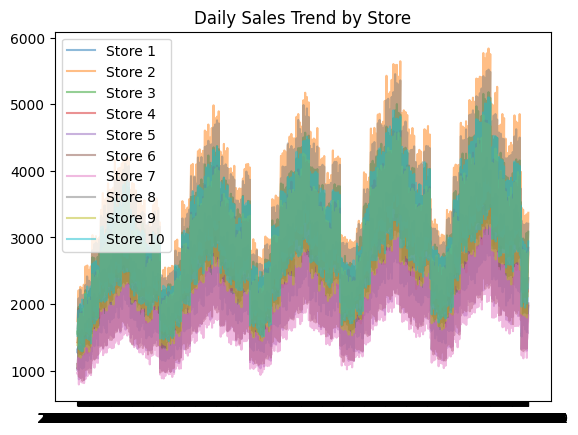

In [ ]:
# 每個store的時間趨勢是否一致
for store_id in train_df['store'].unique():
    store_daily = train_df[train_df['store']==store_id].groupby('date')['sales'].sum()
    plt.plot(store_daily.index, store_daily.values, alpha=0.5, label=f'Store {store_id}')
plt.legend()
plt.title('Daily Sales Trend by Store')
plt.show()

*   10家店的曲線形狀幾乎完全重疊,同樣的季節性、同樣的成長趨勢,只是量級(高度)不同
*   代表季節性/趨勢是全店共通的規律,不需要對每家店分別建模季節性




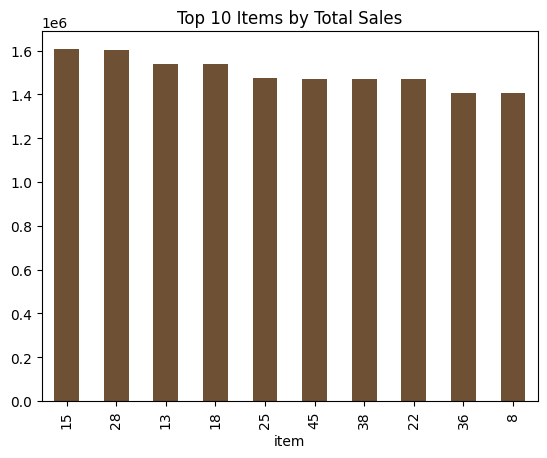

In [ ]:
# item之間的銷量差異
item_sales = train_df.groupby('item')['sales'].sum().sort_values(ascending=False)
item_sales.head(10).plot(kind='bar', color='#6E5034')
plt.title('Top 10 Items by Total Sales')
plt.show()

*   前 10 名銷量差距不大,沒有明顯的 80/20 集中效應
*   代表品項銷量分布相對平均,不是少數幾個爆款撐起大部分業績


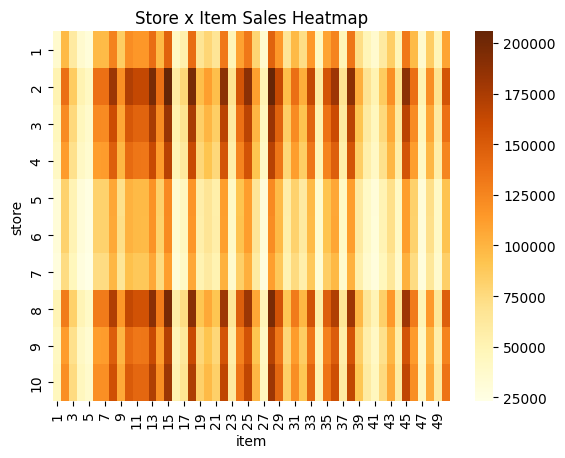

In [ ]:
# heatmap
pivot = train_df.pivot_table(index='store', columns='item', values='sales', aggfunc='sum')
import seaborn as sns
sns.heatmap(pivot, cmap='YlOrBr')
plt.title('Store x Item Sales Heatmap')
plt.show()

*   明顯的橫向條紋(banding)——同一個 item 在不同 store 的深淺模式幾乎一致(例如 item 15、28 在每一家店都偏深)
*   代表哪些品項賣得好這件事不受地區影響,是全店通用的規律,沒有明顯的地區性偏好(regional preference)
*   差異主要來自 store 整體量級不同,不是 item 偏好不同


###  Model

#### Baseline 1：Naive Forecast

In [ ]:
# 用去年同一天的銷量當作今年的預測

# 用 store x item x date 的完整資料
df = train_df.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store', 'item', 'date'])

# 建立去年同期欄位:shift 365 天
df['sales_last_year'] = df.groupby(['store', 'item'])['sales'].shift(365)

# 拿掉沒有去年同期資料的第一年
baseline_df = df.dropna(subset=['sales_last_year'])

# 計算誤差
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

nonzero = baseline_df[baseline_df['sales'] != 0]

mape = mean_absolute_percentage_error(nonzero['sales'], nonzero['sales_last_year'])
rmse = np.sqrt(mean_squared_error(nonzero['sales'], nonzero['sales_last_year']))

print(f'Naive (Last Year) Baseline — MAPE: {mape:.2%}, RMSE: {rmse:.2f}')

Naive (Last Year) Baseline — MAPE: 23.42%, RMSE: 14.96


#### Model 2: Prophet

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


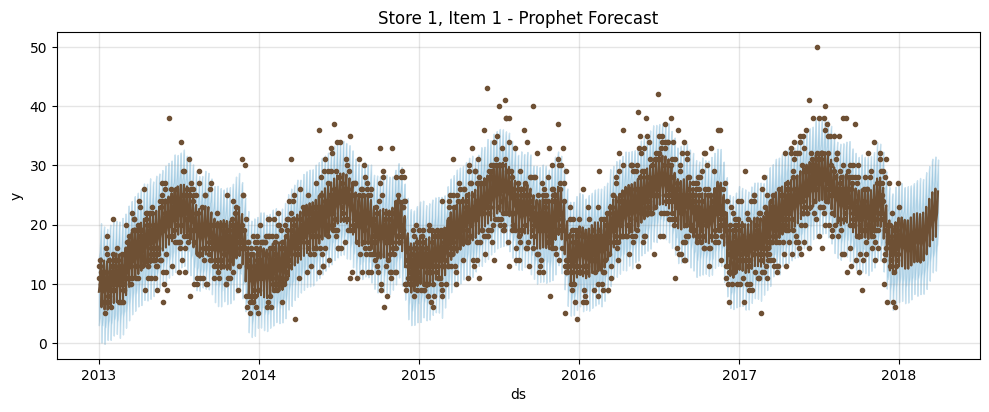

In [ ]:
from prophet import Prophet

# Prophet 需要欄位名稱固定為 ds(日期)和 y(數值)
sample = train_df[(train_df['store']==1) & (train_df['item']==1)][['date','sales']].copy()
sample.columns = ['ds', 'y']

model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(sample)

# 預測未來 3 個月(約 90 天)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

fig1 = model.plot(forecast, figsize=(10, 4))
for line in fig1.axes[0].get_lines():
    line.set_color('#6E5034')
plt.title('Store 1, Item 1 - Prophet Forecast')
plt.show()

*  黑點 = 實際銷量(每天真實資料), 藍線 = Prophet 預測的銷量
*  淺藍色區域 = 信賴區間(uncertainty interval,代表模型對這個預測有多不確定)
*  可以看到藍線很好地抓住了整體的波浪型態(年度成長 + 季節性起伏),黑點雖然分散,但大致圍繞在藍色區域內——代表模型抓到了規律,只是單日的隨機波動本來就無法 100% 預測



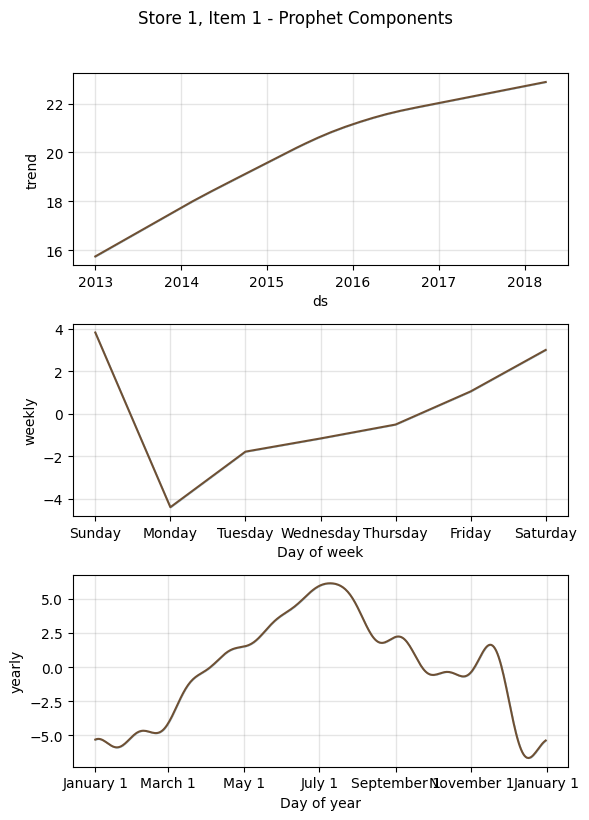

In [ ]:
# trend/seasonality
fig2 = model.plot_components(forecast, figsize=(6, 8))

single_color = '#6E5034'

for ax in fig2.axes:
    for line in ax.lines:
        line.set_color(single_color)

plt.suptitle('Store 1, Item 1 - Prophet Components', y=1.02)
plt.tight_layout()
plt.show()

*   Store 1、Item 1 這個組合的銷量呈線性上升, 跟之前 EDA 看到的全店加總趨勢一致,代表這個品項本身業務在成長
*   Weekly 跟之前手動畫的「Average Sales by Day of Week」結論吻合
*   7 月最高,1 月初/12 月底最低, 對應前面的「夏季銷量高、冬季銷量低」的年度波動模式


In [ ]:
#train
import logging

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

train_df['date'] = pd.to_datetime(train_df['date'])
cutoff_date = train_df['date'].max() - pd.Timedelta(days=90)

results = []

for store_id in train_df['store'].unique():
    for item_id in train_df['item'].unique():
        subset = train_df[(train_df['store']==store_id) & (train_df['item']==item_id)][['date','sales']].copy()
        subset.columns = ['ds', 'y']

        train_part = subset[subset['ds'] <= cutoff_date]
        test_part = subset[subset['ds'] > cutoff_date]

        model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model.fit(train_part)

        future = model.make_future_dataframe(periods=90)
        forecast = model.predict(future)

        pred = forecast[forecast['ds'] > cutoff_date][['ds','yhat']]
        merged = test_part.merge(pred, on='ds')
        merged['store'] = store_id
        merged['item'] = item_id

        results.append(merged)

final_results = pd.concat(results)

In [ ]:
#evaluate
nonzero = final_results[final_results['y'] != 0]

mape = mean_absolute_percentage_error(nonzero['y'], nonzero['yhat'])
rmse = np.sqrt(mean_squared_error(nonzero['y'], nonzero['yhat']))

print(f'Prophet (Full 500 combinations) — MAPE: {mape:.2%}, RMSE: {rmse:.2f}')

In [ ]:
#train (sampled 150)
import logging
import random
import pandas as pd

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

train_df['date'] = pd.to_datetime(train_df['date'])
cutoff_date = train_df['date'].max() - pd.Timedelta(days=90)

random.seed(42)
sample_items = random.sample(list(train_df['item'].unique()), 15)

results = []

for store_id in train_df['store'].unique():
    for item_id in sample_items:
        subset = train_df[(train_df['store']==store_id) & (train_df['item']==item_id)][['date','sales']].copy()
        subset.columns = ['ds', 'y']

        train_part = subset[subset['ds'] <= cutoff_date]
        test_part = subset[subset['ds'] > cutoff_date]

        model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model.fit(train_part)

        future = model.make_future_dataframe(periods=90)
        forecast = model.predict(future)

        pred = forecast[forecast['ds'] > cutoff_date][['ds','yhat']]
        merged = test_part.merge(pred, on='ds')
        merged['store'] = store_id
        merged['item'] = item_id

        results.append(merged)

final_results = pd.concat(results)

In [ ]:
#evaluate
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

nonzero = final_results[final_results['y'] != 0]

mape = mean_absolute_percentage_error(nonzero['y'], nonzero['yhat'])
rmse = np.sqrt(mean_squared_error(nonzero['y'], nonzero['yhat']))

print(f'Prophet (Sampled 150 combinations) — MAPE: {mape:.2%}, RMSE: {rmse:.2f}')

Prophet (Sampled 150 combinations) — MAPE: 13.08%, RMSE: 8.97
